# HOTS Data
Chlorophyll data from Hawaii is gathered from the Hawaii Ocean Time-series (HOTS). More specifically, the Hawaii Ocean Time-series
Data Organization & Graphical System (HOT-DOGS). https://hahana.soest.hawaii.edu/hot/hot-dogs/interface.html

From the Bottle data on HOT-DOGS, each individual station's data is downloaded following these boundries: 
- Time: Jan 01 2000 -Dec 3 2023
-  Depth: 0-200m
-  variables: CTD salinity, CTD Temperature, Bottle Salinity, Fluorometric chlorophyll a,  HPLC cholorophyll a

![hot_bottle](images/HOTS_bottle.png)

Station Locations and file names (https://hahana.soest.hawaii.edu/hot/locations.html):
- Kahe point (1): 21 20.6'N, 158 16.4'W (hd871881.nc)
- Aloha (2) 22 45.0'N, 158 00.0'W (hd117751.nc)
- Kaena (6) 21 50.8'N, 158 21.8'W (hd106854.nc)
- Hale-Aloha (8) 22 27.5'N, 158 7.9'W (hd197174.nc)
- WHOTS1 (ORS) (50) 22 45'N, 157 54.0'W (hd258622.nc)
- WHOTS2 22 (52) 22 40.208'N, 157 57.001'W (hd387759.nc) 


Download similar data from primary prod. with same time and depth, and chlorophyll a values. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import geopandas as gpd
from datetime import datetime
import os
from matplotlib import ticker
import datetime as dt
import plotly.express as px
import cmocean as cm
import cmocean.cm as cmo
import matplotlib.gridspec as gridspec
import time
import matplotlib.ticker as mticker
from PIL import Image

In [2]:
#def to convert degree minutes to degrees for lat and lon 
def dm_to_decimal_degrees(degrees, decimal_minutes):
    """Converts degrees and decimal minutes to decimal degrees.
    args:
        degrees: The whole number of degrees.
        decimal_minutes: The fractional part of the degree, in minutes.
    returns: The equivalent decimal degree value.
    """
    decimal_degrees = degrees + (decimal_minutes / 60)
    return decimal_degrees

#def to input all .nc files from folder 
def get_files(dir):
    file_list = []
    for root, _, files in os.walk(dir): #here, dir would be the path to the files
        for file in files:
            if file.endswith(".nc"):
                file_list.append(os.path.join(root, file)) #if file ends in .nc, append to list 
    return file_list

In [3]:
f_list1 =  'folderto\bottle_data' #folder holding ONLY the bottle data downloaded from HOTS 
f_list = get_files(f_list1) #list of all .nc files from folder

Next, go through each .nc file in the folder, remove any bad dates, and create datetime column. Then, depending on the station (based on value of stn column), append manually the lat and lon of the station, remove flagged chl values, and convert pressure to depth. 

In [4]:
for file in f_list:
    print(file)
    dfs=pd.DataFrame() #initiate empty dataframe
    file2read = netcdf.NetCDFFile(file,'r') #read in the netcdf file
    varrs = file2read.variables #variables in netcdf file
    #remove the dataDesc, which is just a description of the data. if not removed, concatination can't occur
    del varrs["dataDesc"]
    for vars in varrs: #for every variable in the file
    #convert the byte to match specific laptop, and appened the variable column (0) into the dataframe
        dfs[vars]=pd.DataFrame(varrs[vars][:].byteswap().newbyteorder(), columns =['0']) 
        
    dfs=dfs[dfs['mdate']!=-9] #take out any negative datetimes i.e unrecorded data 
    dfs=dfs[dfs['mtime']!=-9]
 #datetime is formatted as mmddyy, and hhmmss, but leading 0s are removed so need to pad with 0s until 6 numbers long
    dfs['mtime'] = [f"{int(t):06d}" for t in dfs['mtime']] 
    dfs['mdate'] = [f"{int(t):06d}" for t in dfs['mdate']] 
    
    dfs['month'] = [int(t[:2]) for t in dfs['mdate']]
    dfs['day'] = [int(t[2:4]) for t in dfs['mdate']]
    dfs['year'] = [int(t[4:])+2000 for t in dfs['mdate']]
    dfs['hour'] = [int(t[:2]) for t in dfs['mtime']]
    dfs['minute'] = [int(t[2:4]) for t in dfs['mtime']]
    dfs['second'] = [int(t[4:]) for t in dfs['mtime']]
    dfs['datetime']= pd.to_datetime(dfs[['year', 'month', 'day', 'hour', 'minute', 'second']]) #datetime variable
    #drop unneeded temporal columns now that datetime is created
    columns_to_drop = ['mtime','mdate','month','day','year','hour','minute','second']
    dfs = dfs.drop(columns=columns_to_drop)
    dfs = dfs.reset_index(drop=True)
    
    #seperate data from each station into it's own dataframe, where the name of the dataframe equals the station name
    #lat and lon are not included in the file, so manually add them
    #finally, roughly convert pressure to depth (Depth(m)=Pressure(db) *1.019716)
    if dfs.stn[0]==1: #station 1 = station Kahe
        kahe=dfs.copy()
        kahe['lat']=dm_to_decimal_degrees(21, 20.6)
        kahe['lon']=dm_to_decimal_degrees(158, 16.4)*-1
        kahe=kahe[kahe['chl']!=-9] #remove -9 i.e. bad chl values
        kahe['station']='kahe'
        kahe['depth'] = kahe['press'] * 1.02
        kahe=kahe[['crn', 'depth', 'chl','hplc', 'datetime', 'lat', 'lon', 'station']]
        
    elif dfs.stn[0]==2: #station 2 = station Aloha
        aloha=dfs.copy()
        aloha['lat']=dm_to_decimal_degrees(22, 45.0)
        aloha['lon']=dm_to_decimal_degrees(158, 00.0)*-1
        #don't remove -9 from chl for aloha station because some bad chl entries still have hplc values. 
        aloha['station']='aloha'
        aloha['depth'] = aloha['press'] * 1.02
        aloha=aloha[['crn', 'depth', 'chl','hplc', 'datetime', 'lat', 'lon', 'station']]

    elif dfs.stn[0]==6: #station 6 = station kaena
        kaena=dfs.copy()
        kaena['lat']=dm_to_decimal_degrees(21, 50.8)
        kaena['lon']=dm_to_decimal_degrees(158, 7.9)*-1
        kaena=kaena[kaena['chl']!=-9] #remove -9 i.e. bad chl values
        kaena['station']='kaena'
        kaena['depth'] = kaena['press'] * 1.02
        kaena=kaena[['crn', 'depth', 'chl','hplc', 'datetime', 'lat', 'lon', 'station']]

    elif dfs.stn[0]==8: #station 8 = station Hale
        hale=dfs.copy()
        hale['lat']=dm_to_decimal_degrees(22, 27.5)
        hale['lon']=dm_to_decimal_degrees(158, 21.8)*-1
        hale=hale[hale['chl']!=-9] #remove -9 i.e. bad chl values
        hale['station']='hale'
        hale['depth'] = hale['press'] * 1.02
        hale=hale[['crn', 'depth', 'chl','hplc', 'datetime', 'lat', 'lon', 'station']]

    elif dfs.stn[0]==50: #station 50 = station Ors
        ors=dfs.copy()
        ors['lat']=dm_to_decimal_degrees(22, 45)
        ors['lon']=dm_to_decimal_degrees(157, 54.0)*-1
        ors=ors[ors['chl']!=-9] #remove -9 i.e. bad chl values
        ors['station']='ors'
        ors['depth'] = ors['press'] * 1.02
        ors=ors[['crn', 'depth', 'chl','hplc', 'datetime', 'lat', 'lon', 'station']]

    elif dfs.stn[0]==52: #station 52 = station Whots
        whots=dfs.copy()
        whots['lat']=dm_to_decimal_degrees(22, 40.208)
        whots['lon']=dm_to_decimal_degrees(157, 57.001)*-1
        whots=whots[whots['chl']!=-9] #remove -9 i.e. bad chl values
        whots['station']='whots'
        whots['depth'] = whots['press'] * 1.02
        whots=whots[['crn', 'depth', 'chl','hplc', 'datetime', 'lat', 'lon', 'station']]

    else:
        print(file) #if noe of the above, print the file to inspect
    file2read.close()  #close file

Once the Bottle data is done, complete the primary prod data.

![hot_bottle](images/hots_pp.png)

For primary production, create datetime column and initialize empty hplc column to match with the bottle data. Primary prod is only recorded at station aloha, so add that lat and lon. 

In [5]:
ppro=pd.DataFrame()
file2read = netcdf.NetCDFFile('hd192096.nc','r')
varrs = file2read.variables #variables
del varrs["dataDesc"]
for vars in varrs:
    ppro[vars]=pd.DataFrame(varrs[vars][:].byteswap().newbyteorder(), columns =['0'])
ppro['stime'] = [f"{int(t):04d}" for t in ppro['stime']] #start time
ppro['etime'] = [f"{int(t):04d}" for t in ppro['etime']] #end time  
ppro['date'] = [f"{int(t):06d}" for t in ppro['date']]  #date

NameError: name 'netcdf' is not defined

In [ ]:
#arbitrarily deciding to use etime (end time) for datetime column
ppro['month'] = [int(t[2:4]) for t in ppro['date']]
ppro['day'] = [int(t[4:]) for t in ppro['date']]
ppro['year'] = [int(t[:2])+2000 for t in ppro['date']]
ppro['hour'] = [int(t[:2]) for t in ppro['etime']]
ppro['minute'] = [int(t[2:4]) for t in ppro['etime']]
ppro['datetime']= pd.to_datetime(ppro[['year', 'month', 'day', 'hour', 'minute']])
ppro=ppro[['crn', 'type', 'depth', 'chl', 'bsal','datetime']].reset_index(drop=True)  
ppro['station']='primary_prod'
ppro['hplc']=-9 #initiate empty hplc column so that when concatinated with stations it matches with other columns
#lat and lon to match station aloha 
ppro['lat']=dm_to_decimal_degrees(22, 45.0)
ppro['lon']=dm_to_decimal_degrees(158, 00.0)*-1

In [ ]:
hots = pd.concat([kahe, aloha, kaena,hale,ors,whots,ppro]).reset_index(drop=True)


## HPLC flag
Some stations recorded HPLC data, under the column name 'hplc'. If it's not recorded, it's entered as -9. So, if a column has hplc recorded, then flag as HPLC and convert to mg/L to match SeaBASS data and rename as chl_a. 

In [ ]:
#HPLC flag: if column hplc = -9, flag as 1 (bad), if there is a value, value, then convert to mg/L and flag as hplc=0
hots['HPLC'] = 1 #assume no HPLC
hots=hots.rename(columns={'hplc':'chl_a'})
hots.loc[hots['chl_a'] != -9, 'HPLC'] = 0 #if hplc column does not equal -9 change to 0
#Based on this linke, https://www.bco-dmo.org/dataset/3773, hplc is in nanograms/L, so need to convert
hots.loc[hots['chl_a'] != -9, 'chl_a'] =hots['chl_a']*0.001


## triplicate flag
Triplicate flags are flagged in the same way the SeaBASS data was, with detecting how many unique depths, datetime, lat, and lon entries there are and flagging if 3 samples were recorded at the exact same time/ hour. 

In [ ]:
counts_series = hots[['depth','datetime','lat','lon']].value_counts() #count how many unique cast,depth, datetime, lat, and lons there are
counts_df = counts_series.reset_index(name='freq_uniq')
hots = pd.merge(hots, counts_df, on=['depth','datetime','lat','lon'], how='left') #add frequency column to original dataframe4

#sometimes, triplicate specific times are recorded (ex: 3:00, 3:05, 3:10 ), so also check for unique datehour entries
hots['date_hour'] = hots['datetime'].dt.strftime('%Y-%m-%d %H')
counts_series = hots[['depth','date_hour','lat','lon']].value_counts() #count how many unique datehour, lat, and lons there are
counts_df = counts_series.reset_index(name='freq_hour')
hots = pd.merge(hots, counts_df, on=['depth','date_hour','lat','lon'], how='left') #add frequency column to original dataframe
hots['triplicate'] = 1 #assume bad unless otherwise said
hots.loc[hots['freq_uniq'] == 3, 'triplicate'] = 0 #if there was a unique datetime, lat, and lon that happened 3 times, triplicate
hots.loc[(hots['freq_uniq'] == 1) &(hots['freq_hour'] == 3), 'triplicate'] = 0 #if 1 unique datetime but 3 unique date hours, assume triplicate


In [ ]:
hots=hots.loc[hots['depth']<=150].reset_index(drop=True) #reduce to upper 150 meteres for algorithm development

hots=hots[['datetime', 'lat', 'lon','depth', 'chl', 'chl_a', 'station', 'HPLC', 'triplicate']]
hots['experiment']='HOTS'
hots['source']='HOT-DOGS'
hots['investigators']= 'Angelicque E. White'
hots['affiliations']="University of Hawai'i at Mānoa"
hots['url']='https://hahana.soest.hawaii.edu/hot/hot-dogs/interface.html'
hots.replace(-9, np.nan, inplace=True)
hots = hots.dropna(subset=['chl', 'chl_a'], how='all')

Done with Hots data!! 

Data obtained via the Hawaii Ocean Time-series HOT-DOGS application; University of Hawai'i at Mānoa. National Science Foundation Award # 2241005

## Plots

In [2]:
HOTS = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\hots_chl_qc.xlsx')


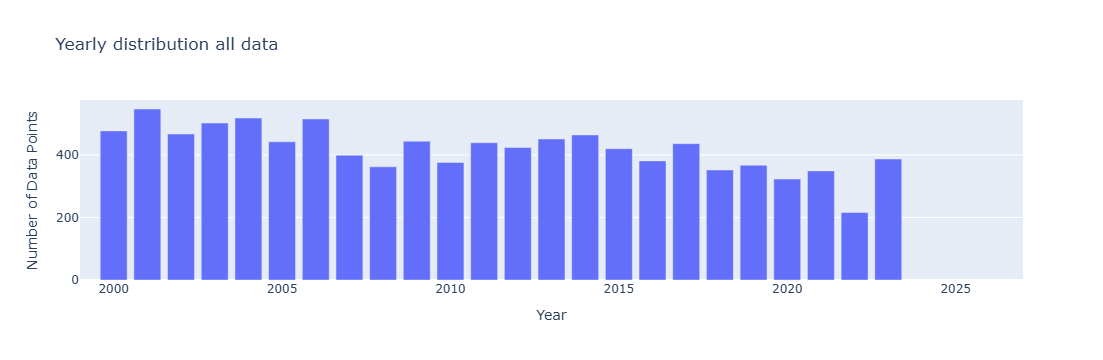

In [3]:
year_test=HOTS.copy()
year_test['datetime'] = pd.to_datetime(year_test['datetime'])
year_test['year'] = year_test['datetime'].dt.year
grouped = year_test.groupby(['year']).size().reset_index(name='DataPoints')

# Create bar chart
fig = px.bar(grouped,x='year', y='DataPoints', title='Yearly distribution all data',
             labels={'year': 'Year', 'DataPoints': 'Number of Data Points', 'metadata': 'Metadata'},)
fig.update_xaxes(range=[1999,2027])
fig.update_layout(barmode='stack')  # ensures stacking
fig.show()

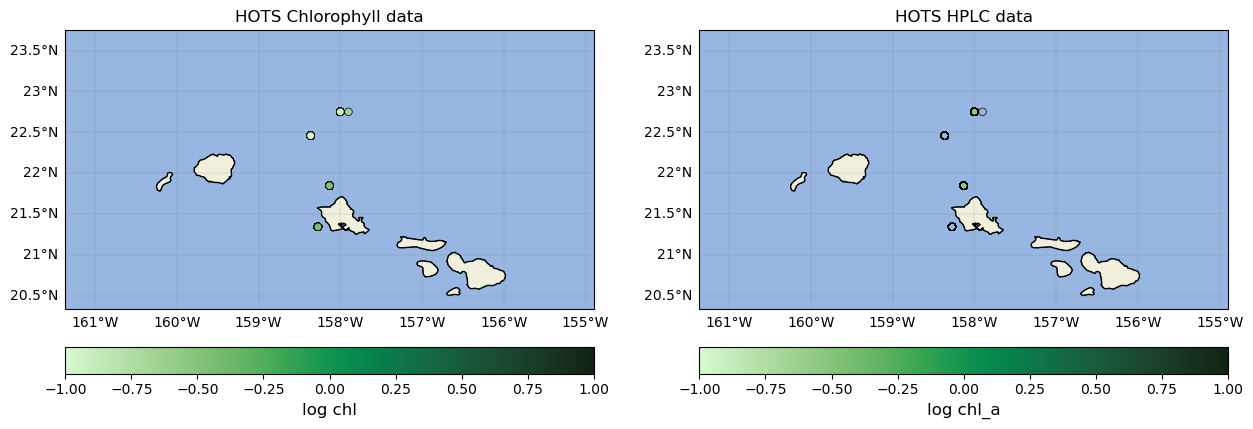

In [16]:
year_test['log_chl']=np.log10(year_test['chl'])
year_test['log_chl_a']=np.log10(year_test['chl_a'])

fig=plt.figure(figsize=(15, 10))
axs1=fig.add_subplot(1,2,1,projection= cartopy.crs.PlateCarree())
axs1.add_feature(cfeature.LAND)
axs1.add_feature(cfeature.OCEAN)
axs1.add_feature(cfeature.COASTLINE)
axs1.add_feature(cfeature.BORDERS)
axs1.add_feature(cfeature.STATES, linestyle='-', linewidth=0.5)
im=axs1.scatter(year_test.lon,year_test.lat,c=year_test.log_chl,cmap=cmo.algae,s=30,vmin=-1, vmax=1, edgecolors='black', linewidths=0.5)
axs1.set_title('HOTS Chlorophyll data')
axs1.set_xlim(min(year_test.lon)-3,max(year_test.lon)+3)
axs1.set_ylim(min(year_test.lat)-1,max(year_test.lat)+1)
cb=fig.colorbar(im,ax=axs1,orientation='horizontal', pad=0.05)
cb.set_label('log chl',fontsize=12)
gl=axs1.gridlines(linewidth=0.2,color='grey',alpha=0.7,linestyle='-', draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels

axs2=fig.add_subplot(1,2,2,projection= cartopy.crs.PlateCarree())
axs2.add_feature(cfeature.LAND)
axs2.add_feature(cfeature.OCEAN)
axs2.add_feature(cfeature.COASTLINE)
axs2.add_feature(cfeature.BORDERS)
axs2.add_feature(cfeature.STATES, linestyle='-', linewidth=0.5)
im=axs2.scatter(year_test.lon,year_test.lat,c=year_test.log_chl_a,cmap=cmo.algae,s=30,vmin=-1, vmax=1, edgecolors='black', linewidths=0.5)
axs2.set_title('HOTS HPLC data')
axs2.set_xlim(min(year_test.lon)-3,max(year_test.lon)+3)
axs2.set_ylim(min(year_test.lat)-1,max(year_test.lat)+1)
cb=fig.colorbar(im,ax=axs2,orientation='horizontal', pad=0.05)
cb.set_label('log chl_a',fontsize=12)
gl=axs2.gridlines(linewidth=0.2,color='grey',alpha=0.7,linestyle='-', draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels

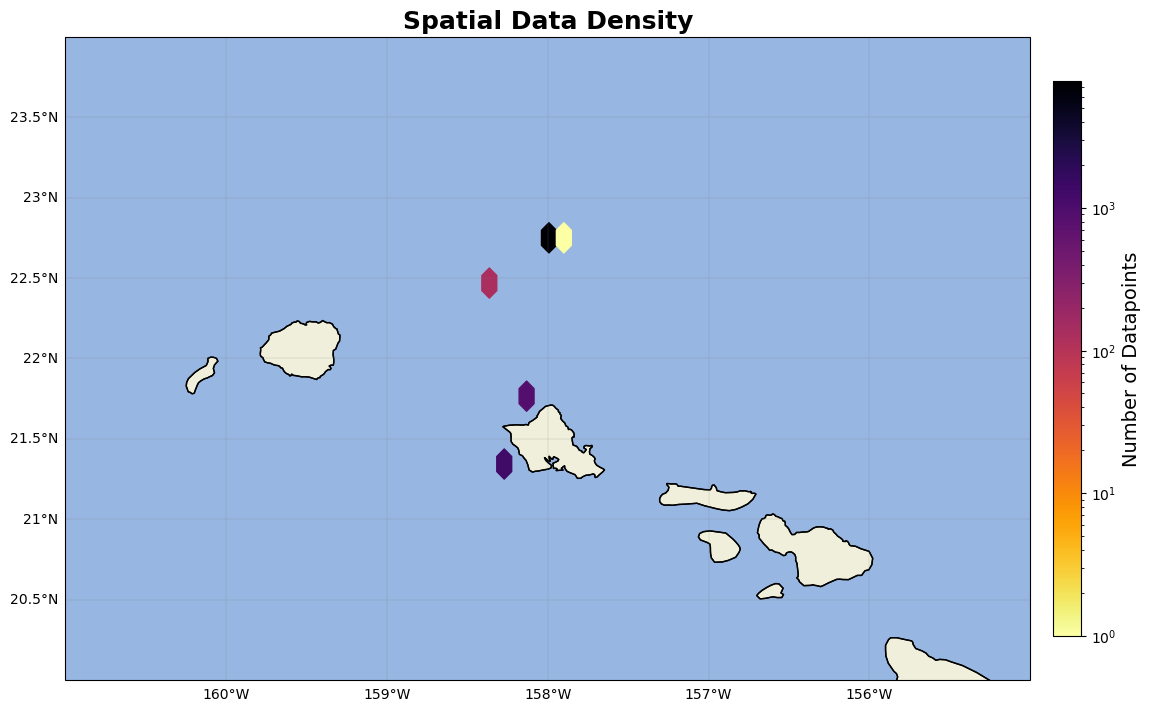

In [10]:
from matplotlib.colors import LogNorm # Important for high-variance data
fig = plt.figure(figsize=(15, 9))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)
hb = ax.hexbin(year_test.lon, year_test.lat, gridsize=(5,5), cmap='inferno_r', mincnt=1, transform=ccrs.PlateCarree(),norm=LogNorm()) 
cb = plt.colorbar(hb, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
cb.set_label('Number of Datapoints', fontsize=14)
gl=ax.gridlines(linewidth=0.2,color='grey',alpha=0.7,linestyle='-', draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels
ax.set_extent([-161, -155, 20, 24], crs=ccrs.PlateCarree())

ax.set_title('Spatial Data Density', fontsize=18, fontweight='bold')

plt.show()